# Web Scraping HTML Google Books

Kelompok 2 :<br>
Muhammad Refi Setyawan (159) <br>
Doni Wahana Putra (248)



Library yang dibutuhkan (jalankan sekali di sel baru jika belum tersedia):
```python
%pip install requests pandas beautifulsoup4 nltk Sastrawi demoji matplotlib wordcloud
```
Resource NLTK diunduh sekali saat blok Text Processing dijalankan.


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd


## 1. Mengambil halaman HTML

In [ ]:
book_id = 'ZPi96HIG76AC'
url = f'https://books.google.com/books?id={book_id}'

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/148.0 Safari/537.36'
}

page = requests.get(url, headers=headers, timeout=30)

print('Status code:', page.status_code)
print('Panjang HTML:', len(page.text))

page.raise_for_status()


Status code: 200
Panjang HTML: 330072


## 2. Parsing HTML dengan BeautifulSoup


In [ ]:
soup = BeautifulSoup(page.text, 'html.parser')

print(soup.title.get_text(strip=True) if soup.title else 'Title tidak ditemukan')


The Rainbow Troops - Andrea Hirata, Angie Kilbane - Google Buku


## 3. Melihat teks halaman


In [ ]:
text = soup.get_text(' ', strip=True)
print(text[:5000])


The Rainbow Troops - Andrea Hirata, Angie Kilbane - Google Buku Login Bidang tersembunyi Buku Koleksiku Bantuan Penelusuran Buku Lanjutan Dapatkan buku cetak eBuku tidak tersedia Mizan Store BukuKita.com Gramedia Cari di perpustakaan Semua penjual » The Rainbow Troops Andrea Hirata , Angie Kilbane Bentang Pustaka , 1 Des 2009 - 470 halaman Andrea Hirata is an Indonesian novelist. His debut novel The Rainbow Troops (known as Laskar Pelangi in Indonesia) shattered national sales records, making him the best selling author in Indonesia to date, reached over 5 millions readers, and contributed significantly to the development of modern Indonesian literature. The Rainbow Troops, set on Belitong Island, Indonesia, tells the story of a tight-knit group of students and their teachers fighting for education and dignity, even as they face continual hardship. Fabulously rich in natural resources, Belitong is also home to chronic poverty and educational discrimination. This amazing story tells of 

## 4. Mengambil metadata buku

Deskripsi diambil dari `#synopsistext`; jika tidak ada, dicari pada selector lain, metadata description, atau JSON-LD. `og:description` tidak selalu tersedia.


In [ ]:
import json

def extract_description(soup):
    # Google Books menaruh sinopsis di DOM, bukan selalu di Open Graph.
    for selector in ['#synopsistext', '[itemprop="description"]',
                     '#description', '.book_description']:
        element = soup.select_one(selector)
        if element is not None:
            value = element.get('content') or element.get_text(' ', strip=True)
            if value and value.strip():
                return value.strip(), selector
    for attrs in [{'property': 'og:description'}, {'name': 'description'},
                  {'name': 'twitter:description'}]:
        element = soup.find('meta', attrs=attrs)
        if element and element.get('content', '').strip():
            return element['content'].strip(), str(attrs)

    def find_book_description(value):
        if isinstance(value, list):
            for item in value:
                result = find_book_description(item)
                if result:
                    return result
        elif isinstance(value, dict):
            kind = value.get('@type', [])
            kinds = [kind] if isinstance(kind, str) else kind
            if 'Book' in kinds and isinstance(value.get('description'), str):
                return value['description'].strip()
            return find_book_description(value.get('@graph', []))
        return ''

    for script in soup.find_all('script', attrs={'type': 'application/ld+json'}):
        try:
            value = find_book_description(json.loads(script.get_text()))
        except (ValueError, TypeError):
            continue
        if value:
            return value, 'JSON-LD Book.description'
    return '', 'deskripsi tidak ditemukan dalam HTML'

meta_title = soup.find('meta', attrs={'property': 'og:title'})
title = meta_title.get('content') if meta_title else None
if not title and soup.title:
    title = soup.title.get_text(strip=True).split(' - ')[0]
description, description_source = extract_description(soup)
meta_image = soup.find('meta', attrs={'property': 'og:image'})
image = meta_image.get('content') if meta_image else None

print('Judul           :', title)
print('Deskripsi       :', description if description else '[tidak tersedia]')
print('Sumber deskripsi:', description_source)
print('Gambar          :', image)


Judul           : The Rainbow Troops
Deskripsi       : Andrea Hirata is an Indonesian novelist. His debut novel The Rainbow Troops (known as Laskar Pelangi in Indonesia) shattered national sales records, making him the best selling author in Indonesia to date, reached over 5 millions readers, and contributed significantly to the development of modern Indonesian literature. The Rainbow Troops, set on Belitong Island, Indonesia, tells the story of a tight-knit group of students and their teachers fighting for education and dignity, even as they face continual hardship. Fabulously rich in natural resources, Belitong is also home to chronic poverty and educational discrimination. This amazing story tells of a persistent young teacher and her tireless efforts to fight for her ten students' right to an education. Together, they take the reader on a journey through the beauty of childhood friendship, the inspiration of love, and the power of education. The students' magnetic personalities and

## 5. Mengambil semua metadata Open Graph


In [ ]:
og_data = {}

for meta in soup.find_all('meta'):
    prop = meta.get('property')
    content = meta.get('content')
    if prop and prop.startswith('og:') and content:
        og_data[prop] = content

for key, value in og_data.items():
    print(f'{key}: {value}')


og:url: https://books.google.com/books/about/The_Rainbow_Troops.html?hl=id&id=ZPi96HIG76AC
og:title: The Rainbow Troops
og:type: book
og:site_name: Google Books
og:image: https://books.google.co.id/books/content?id=ZPi96HIG76AC&printsec=frontcover&img=1&zoom=1&edge=curl&imgtk=AFLRE718I649sdmYMHGh5HcCKq-2kmGCiaFLPmqT78F1LHTuLo9rZZ-fgr2LSbGM93QVnenuDdQ1dPR19iUcrh68z2ohepuBVnqCAP1rImg_IJEiywh0UybPgZsvEHVUuh20aOGT_0XA


## 6. Membuat DataFrame


In [ ]:
data = {
    'id': [book_id], 'judul': [title], 'deskripsi': [description],
    'sumber_deskripsi': [description_source], 'gambar': [image], 'url': [url]
}
df = pd.DataFrame(data)
df


,id,judul,deskripsi,sumber_deskripsi,gambar,url
0,ZPi96HIG76AC,The Rainbow Troops,Andrea Hirata is an Indonesian novelist. His d...,#synopsistext,https://books.google.co.id/books/content?id=ZP...,https://books.google.com/books?id=ZPi96HIG76AC


## 7. Pemeriksaan HTML untuk mencari selector tambahan


In [ ]:
for tag in soup.find_all(['div', 'span', 'p', 'a'], limit=1000):
    classes = tag.get('class', [])
    text_tag = tag.get_text(' ', strip=True)
    if any(word in str(classes).lower() for word in ['book', 'title', 'author', 'rating']):
        if text_tag:
            print('TAG:', tag.name)
            print('CLASS:', classes)
            print('TEXT:', text_tag[:200])
            print('-' * 60)


TAG: div
CLASS: ['bookinfo_sectionwrap']
TEXT: Andrea Hirata , Angie Kilbane Bentang Pustaka , 1 Des 2009 - 470 halaman
------------------------------------------------------------


## Text Processing - Chapter 4



,judul,status_processing,bahasa_deskripsi,text,prepro,token_sebelum,token_setelah
0,The Rainbow Troops,diproses,en,Andrea Hirata is an Indonesian novelist. His d...,andrea hirata indonesian novelist debut novel ...,287,189


,judul,clean_text,rm_stopwords,stem,lemma_en,rm_frequent_demo,rm_rare_demo
0,The Rainbow Troops,andrea hirata is an indonesian novelist his de...,andrea hirata indonesian novelist debut novel ...,andrea hirata indonesian novelist debut novel ...,andrea hirata indonesian novelist debut novel ...,andrea hirata indonesian novelist debut novel ...,indonesian novel rainbow troops indonesia best...


Record sumber: 1
Deskripsi tersedia: 1
Deskripsi kosong: 0
Deskripsi unik: 1


,bahasa,kata,frekuensi
0,en,film,12
1,en,festival,6
2,en,best,5
3,en,indonesia,5
4,en,award,4
5,en,international,4
6,en,rainbow,4
7,en,troops,4
8,en,education,3
9,en,indonesian,3


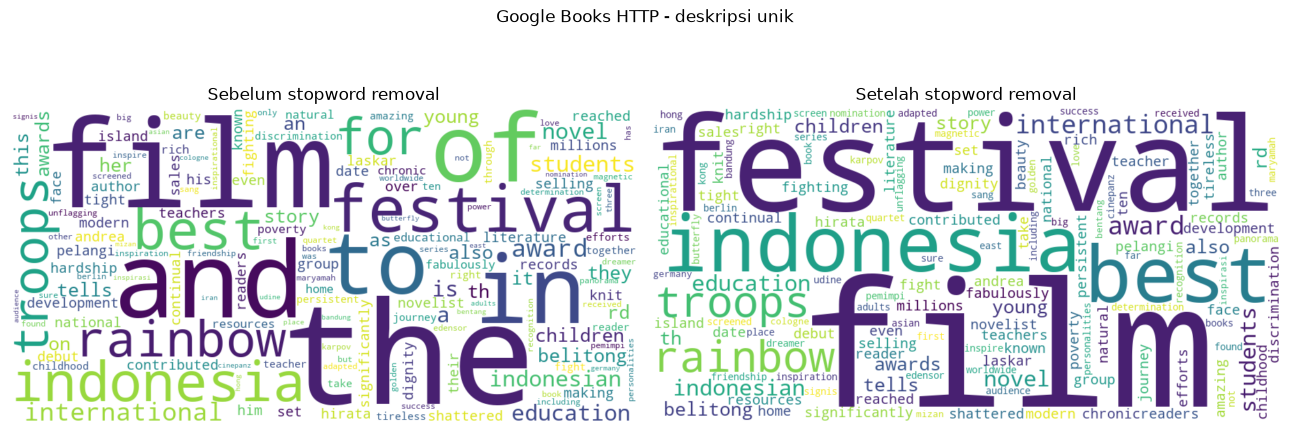

CSV hasil tersimpan: hasil_text_processing_http


In [ ]:
# Seluruh proses Chapter 4 dijadikan satu blok dan memakai df hasil scraping di atas.
from pathlib import Path
from collections import Counter
import os
import re
import json
import unicodedata
import pandas as pd
from bs4 import BeautifulSoup
import demoji
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from IPython.display import display

METHOD = 'HTTP'
output_dir = Path.cwd() / ('hasil_text_processing_' + METHOD.lower())
output_dir.mkdir(exist_ok=True)
nltk_dir = Path(os.environ.get('NLTK_DATA', str(Path.cwd() / '.nltk_data')))
nltk_dir.mkdir(parents=True, exist_ok=True)
if str(nltk_dir) not in nltk.data.path:
    nltk.data.path.insert(0, str(nltk_dir))
for resource, locator in {
    'stopwords': 'corpora/stopwords', 'wordnet': 'corpora/wordnet',
    'averaged_perceptron_tagger_eng': 'taggers/averaged_perceptron_tagger_eng',
}.items():
    try:
        nltk.data.find(locator)
    except LookupError:
        try:
            nltk.data.find(locator + '.zip')
        except LookupError:
            if not nltk.download(resource, download_dir=str(nltk_dir), quiet=True):
                raise RuntimeError('Gagal mengunduh resource NLTK: ' + resource)

if 'deskripsi' not in df.columns:
    raise ValueError('Jalankan scraping dan pembuatan DataFrame terlebih dahulu.')
df_processed = df.copy()
df_processed['metode'] = METHOD
df_processed['text'] = df_processed['deskripsi'].fillna('').astype(str).str.strip()
df_processed['status_processing'] = df_processed['text'].map(
    lambda value: 'diproses' if value else 'deskripsi kosong - dilewati')

def remove_html(value):
    parsed = BeautifulSoup(str(value), 'html.parser')
    for tag in parsed(['script', 'style']):
        tag.decompose()
    return unicodedata.normalize('NFKC', parsed.get_text(' ', strip=True))

def remove_urls_email(value):
    value = re.sub(r'\b(?:https?://|www\.)\S+', ' ', value)
    return re.sub(r'\b[\w.+-]+@[\w.-]+\.[a-z]{2,}\b', ' ', value, flags=re.I)

def remove_emoji_emoticon(value):
    value = demoji.replace(value, ' ')
    return re.sub(r'(?::|;|=|8)[\-^]?[)(/\\|DPpOo]+', ' ', value)

def remove_punctuation(value):
    return ''.join(' ' if unicodedata.category(char)[0] in {'P', 'S'} else char
                   for char in value)

def normalize_space(value):
    return re.sub(r'\s+', ' ', value).strip()

df_processed['rm_html'] = df_processed['text'].map(remove_html)
df_processed['rm_hashtag'] = df_processed['rm_html'].map(lambda x: re.sub(r'#\w+', ' ', x))
df_processed['lower_case'] = df_processed['rm_hashtag'].str.lower()
df_processed['rm_url_email'] = df_processed['lower_case'].map(remove_urls_email)
df_processed['rm_emoji'] = df_processed['rm_url_email'].map(remove_emoji_emoticon)
df_processed['rm_punc'] = df_processed['rm_emoji'].map(remove_punctuation)
df_processed['rm_number'] = df_processed['rm_punc'].map(lambda x: re.sub(r'\d+', ' ', x))
df_processed['clean_text'] = df_processed['rm_number'].map(normalize_space)
df_processed['tokens'] = df_processed['clean_text'].str.split()

# Bahasa buku dari API dapat berbeda dengan bahasa teks deskripsinya.
# Bandingkan kata fungsi en/id; jika tidak ada petunjuk, gunakan metadata.
sw = {language: set(stopwords.words(name)) for language, name in
      [('en', 'english'), ('id', 'indonesian')]}
negations = {'en': {'no', 'not', 'nor'}, 'id': {'tidak', 'bukan', 'belum', 'jangan'}}

def choose_language(row):
    if not row['tokens']:
        return 'kosong'
    scores = {language: sum(t in words for t in row['tokens']) for language, words in sw.items()}
    if scores['en'] > scores['id']:
        return 'en'
    if scores['id'] > scores['en']:
        return 'id'
    hint = row.get('bahasa_buku', '')
    return hint if hint in sw else 'lainnya'

df_processed['bahasa_deskripsi'] = df_processed.apply(choose_language, axis=1)
filtered_sw = {language: words - negations[language] for language, words in sw.items()}
df_processed['tokens_no_stopwords'] = df_processed.apply(
    lambda row: [t for t in row['tokens']
                 if t not in filtered_sw.get(row['bahasa_deskripsi'], set())], axis=1)
df_processed['rm_stopwords'] = df_processed['tokens_no_stopwords'].map(' '.join)
porter = PorterStemmer()
id_stemmer = StemmerFactory().create_stemmer()
lemmatizer = WordNetLemmatizer()

def stem_row(row):
    if row['bahasa_deskripsi'] == 'en':
        return ' '.join(porter.stem(t) for t in row['tokens_no_stopwords'])
    if row['bahasa_deskripsi'] == 'id':
        return id_stemmer.stem(row['rm_stopwords'])
    return row['rm_stopwords']

def lemma_row(row):
    if row['bahasa_deskripsi'] != 'en':
        return ''  # WordNet Inggris tidak diterapkan pada bahasa lain.
    mapping = {'J': wordnet.ADJ, 'V': wordnet.VERB, 'N': wordnet.NOUN, 'R': wordnet.ADV}
    lemmas = [lemmatizer.lemmatize(t, mapping.get(tag[0], wordnet.NOUN))
              for t, tag in nltk.pos_tag(row['tokens'])]
    return ' '.join(t for t in lemmas if t not in filtered_sw['en'])

df_processed['stem'] = df_processed.apply(stem_row, axis=1)
df_processed['lemma_en'] = df_processed.apply(lemma_row, axis=1)
df_processed['prepro'] = df_processed['stem']
df_processed['token_sebelum'] = df_processed['text'].map(lambda x: len(x.split()))
df_processed['token_setelah'] = df_processed['prepro'].map(lambda x: len(x.split()))

# Filter frequent/rare hanya contoh: jangan menghilangkan istilah penting pada korpus kecil.
unique = df_processed.loc[df_processed['clean_text'].ne('')].drop_duplicates('clean_text')
language_counts = {language: Counter(t for tokens in group['tokens_no_stopwords'] for t in tokens)
                   for language, group in unique.groupby('bahasa_deskripsi')}
top_words = {language: set(w for w, count in sorted(counts.items(), key=lambda x: (-x[1], x[0]))[:3])
             for language, counts in language_counts.items()}
rare_words = {language: {w for w, count in counts.items() if count == 1}
              for language, counts in language_counts.items()}
for column, word_sets in [('rm_frequent_demo', top_words), ('rm_rare_demo', rare_words)]:
    df_processed[column] = df_processed.apply(
        lambda row: ' '.join(t for t in row['tokens_no_stopwords']
                             if t not in word_sets.get(row['bahasa_deskripsi'], set())), axis=1)
freq_records = [{'bahasa': language, 'kata': word, 'frekuensi': count}
                for language, counts in language_counts.items()
                for word, count in sorted(counts.items(), key=lambda x: (-x[1], x[0]))]
df_frequency = pd.DataFrame(freq_records, columns=['bahasa', 'kata', 'frekuensi'])

display(df_processed[['judul', 'status_processing', 'bahasa_deskripsi', 'text',
                      'prepro', 'token_sebelum', 'token_setelah']])
display(df_processed[['judul', 'clean_text', 'rm_stopwords', 'stem', 'lemma_en',
                      'rm_frequent_demo', 'rm_rare_demo']])
print('Record sumber:', len(df_processed))
print('Deskripsi tersedia:', int(df_processed['text'].ne('').sum()))
print('Deskripsi kosong:', int(df_processed['text'].eq('').sum()))
print('Deskripsi unik:', len(unique))
display(df_frequency.head(15))

before = Counter(t for tokens in unique['tokens'] for t in tokens)
after = Counter(t for tokens in unique['tokens_no_stopwords'] for t in tokens)
if after:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, counts, label in zip(axes, [before, after],
                                ['Sebelum stopword removal', 'Setelah stopword removal']):
        cloud = WordCloud(width=900, height=450, background_color='white',
                          random_state=42, collocations=False).generate_from_frequencies(counts)
        ax.imshow(cloud, interpolation='bilinear')
        ax.set_title(label)
        ax.axis('off')
    fig.suptitle('Google Books ' + METHOD + ' - deskripsi unik')
    fig.tight_layout()
    fig.savefig(output_dir / 'wordcloud.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Tidak ada token untuk visualisasi.')

export = df_processed.copy()
for column in ['tokens', 'tokens_no_stopwords']:
    export[column] = export[column].map(lambda tokens: json.dumps(tokens, ensure_ascii=False))
export.to_csv(output_dir / ('google_books_' + METHOD.lower() + '_preprocessed.csv'),
              index=False, encoding='utf-8-sig')
df_frequency.to_csv(output_dir / 'frekuensi_kata.csv', index=False, encoding='utf-8-sig')
print('CSV hasil tersimpan:', output_dir.name)
